In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm.auto import tqdm

DATA_PATH = Path("data/311_data.csv")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: AMD Radeon Graphics


(null): No such file or directory


In [2]:
def keep_top_categories(series, top_n=20):
    s = series.astype("string").fillna("Missing").astype(str).str.strip().replace("", "Missing")
    top_values = s.value_counts().head(top_n).index
    return s.where(s.isin(top_values), "Other").astype(str)


use_columns = [
    "Created Date",
    "Closed Date",
    "Problem Detail (formerly Descriptor)",
    "Location Type",
    "Borough",
]

raw_df = pd.read_csv(DATA_PATH, usecols=use_columns, low_memory=False)
raw_df["Created Date"] = pd.to_datetime(raw_df["Created Date"], errors="coerce")
raw_df["Closed Date"] = pd.to_datetime(raw_df["Closed Date"], errors="coerce")

raw_df["resolution_hours"] = (raw_df["Closed Date"] - raw_df["Created Date"]).dt.total_seconds() / 3600
raw_df = raw_df[
    raw_df["Created Date"].notna()
    & raw_df["Closed Date"].notna()
    & (raw_df["resolution_hours"] > 0)
].copy()

resolution_cap_hours = raw_df["resolution_hours"].quantile(0.95)
raw_df["resolution_hours_capped"] = raw_df["resolution_hours"].clip(upper=resolution_cap_hours)
raw_df["log_resolution_hours"] = np.log1p(raw_df["resolution_hours_capped"])

raw_df["created_hour"] = raw_df["Created Date"].dt.hour
raw_df["created_dayofweek"] = raw_df["Created Date"].dt.day_name()
raw_df["created_month"] = raw_df["Created Date"].dt.month

ml_df_base = raw_df.copy()

print("Base rows:", len(ml_df_base))
print("Cap (95th percentile hours):", round(resolution_cap_hours, 3))

/tmp/ipykernel_26514/205751375.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_df["Created Date"] = pd.to_datetime(raw_df["Created Date"], errors="coerce")
/tmp/ipykernel_26514/205751375.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_df["Closed Date"] = pd.to_datetime(raw_df["Closed Date"], errors="coerce")


Base rows: 6297084
Cap (95th percentile hours): 1134.497


In [3]:
feature_config = {
    "drop_descriptor_values": ["Other", "NYPD", "News Gathering"],
    "descriptor_top_n": 20,
    "location_type_top_n": 10,
    "selected_features": [
        "descriptor_top",
        "borough_clean",
        "location_type_top",
        "created_dayofweek",
        "created_hour",
        "created_month",
    ],
}

ml_df_experiment = ml_df_base.copy()
ml_df_experiment["descriptor"] = ml_df_experiment["Problem Detail (formerly Descriptor)"].astype(str)
ml_df_experiment = ml_df_experiment[
    ~ml_df_experiment["descriptor"].isin(feature_config["drop_descriptor_values"])
].copy()

ml_df_experiment["descriptor_top"] = keep_top_categories(
    ml_df_experiment["descriptor"],
    top_n=feature_config["descriptor_top_n"],
)
ml_df_experiment["location_type_top"] = keep_top_categories(
    ml_df_experiment["Location Type"],
    top_n=feature_config["location_type_top_n"],
)
ml_df_experiment["borough_clean"] = ml_df_experiment["Borough"].astype(str)

selected_features = feature_config["selected_features"]
ml_df_experiment = ml_df_experiment.dropna(
    subset=selected_features + ["log_resolution_hours"]
).copy()

print("Experiment rows:", len(ml_df_experiment))
print("Features:", selected_features)

Experiment rows: 6259821
Features: ['descriptor_top', 'borough_clean', 'location_type_top', 'created_dayofweek', 'created_hour', 'created_month']


In [4]:
X = pd.get_dummies(ml_df_experiment[selected_features], drop_first=True, dtype=float)
y = ml_df_experiment["log_resolution_hours"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
)

X_train_np = X_train.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)
y_train_np = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
y_test_np = y_test.to_numpy(dtype=np.float32).reshape(-1, 1)

X_mean = X_train_np.mean(axis=0, keepdims=True)
X_std = X_train_np.std(axis=0, keepdims=True)
X_std[X_std == 0] = 1.0

X_train_scaled = (X_train_np - X_mean) / X_std
X_test_scaled = (X_test_np - X_mean) / X_std

print("X shape:", X.shape)
print("Train/Test:", X_train.shape, X_test.shape)

X shape: (6259821, 43)
Train/Test: (5007856, 43) (1251965, 43)


In [5]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train_np, dtype=torch.float32),
)

batch_size = 8192
num_workers = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
    num_workers=num_workers,
    persistent_workers=num_workers > 0,
    prefetch_factor=4 if num_workers > 0 else None,
)

model = nn.Sequential(
    nn.Linear(X_train_scaled.shape[1], 512),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

X_val_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)
y_val_t = torch.tensor(y_test_np, dtype=torch.float32, device=device)

best_loss = float("inf")
best_state = None
patience = 5
no_improve = 0
n_epochs = 30

epoch_history = {
    "epoch": [],
    "train_mse": [],
    "val_mse": [],
    "val_r2": [],
}

print(f"Batches per epoch: {len(train_loader):,}")
print(f"Max total batches: {len(train_loader) * n_epochs:,}")
print(f"batch_size={batch_size}, num_workers={num_workers}")

for epoch in tqdm(range(n_epochs), desc="Epochs", position=0):
    model.train()
    running_loss = 0.0

    batch_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{n_epochs}",
        leave=False,
        position=1,
        mininterval=1.0,
    )

    for xb, yb in batch_bar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
            pred = model(xb)
            loss = criterion(pred, yb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        batch_bar.set_postfix(train_mse=f"{loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()

    val_pred_np = val_pred.detach().cpu().numpy().reshape(-1)
    val_true_np = y_val_t.detach().cpu().numpy().reshape(-1)
    val_r2 = r2_score(val_true_np, val_pred_np)

    avg_train_loss = running_loss / len(train_loader)
    epoch_history["epoch"].append(epoch + 1)
    epoch_history["train_mse"].append(avg_train_loss)
    epoch_history["val_mse"].append(val_loss)
    epoch_history["val_r2"].append(val_r2)

    tqdm.write(
        f"Epoch {epoch+1:03d} | train_mse={avg_train_loss:.4f} | val_mse={val_loss:.4f} | val_r2={val_r2:.4f} | best={best_loss:.4f}"
    )

    if val_loss < best_loss:
        best_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        tqdm.write(f"Early stopping at epoch {epoch+1}")
        break

if best_state is not None:
    model.load_state_dict(best_state)
model.to(device)

history_df = pd.DataFrame(epoch_history)
print("Best validation MSE:", round(best_loss, 4))

Batches per epoch: 612
Max total batches: 18,360
batch_size=8192, num_workers=8


/tmp/ipykernel_26514/883087579.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30:   0%|          | 0/612 [00:01<?, ?it/s]

Epoch 001 | train_mse=1.6389 | val_mse=1.4790 | val_r2=0.6854 | best=inf


...

Epoch 007 | train_mse=1.4558 | val_mse=1.4978 | val_r2=0.6814 | best=1.4578


Epoch 8/30:   0%|          | 0/612 [00:00<?, ?it/s]

Epoch 008 | train_mse=1.4540 | val_mse=1.5079 | val_r2=0.6793 | best=1.4578


Epoch 9/30:   0%|          | 0/612 [00:00<?, ?it/s]

Epoch 009 | train_mse=1.4523 | val_mse=1.4632 | val_r2=0.6888 | best=1.4578
Early stopping at epoch 9
Best validation MSE: 1.4578


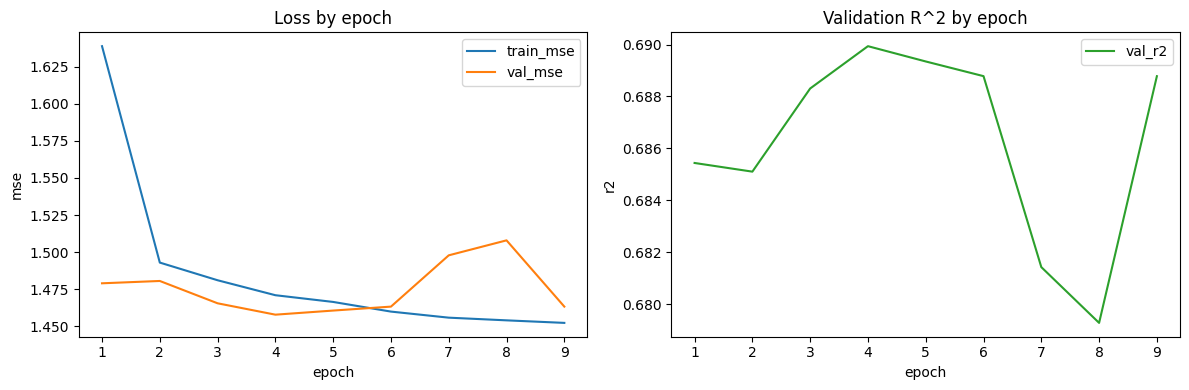

,epoch,train_mse,val_mse,val_r2
4,5,1.466389,1.460577,0.689348
5,6,1.459882,1.463236,0.688783
6,7,1.455788,1.497822,0.681427
7,8,1.453975,1.507923,0.679279
8,9,1.452265,1.463243,0.688781


In [6]:
if len(history_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_mse"], label="train_mse")
    axes[0].plot(history_df["epoch"], history_df["val_mse"], label="val_mse")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("mse")
    axes[0].set_title("Loss by epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["val_r2"], color="tab:green", label="val_r2")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("r2")
    axes[1].set_title("Validation R^2 by epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

history_df.tail()

In [7]:
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)
    y_pred_log = model(X_test_t).detach().cpu().numpy().reshape(-1)

y_true_log = y_test_np.reshape(-1)

rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
mae_log = mean_absolute_error(y_true_log, y_pred_log)
r2_log = r2_score(y_true_log, y_pred_log)

y_true_hours = np.expm1(y_true_log)
y_pred_hours = np.expm1(np.clip(y_pred_log, a_min=0, a_max=None))
rmse_hours = np.sqrt(mean_squared_error(y_true_hours, y_pred_hours))
mae_hours = mean_absolute_error(y_true_hours, y_pred_hours)

print("Test RMSE (log):", round(rmse_log, 4))
print("Test MAE (log):", round(mae_log, 4))
print("Test R^2 (log):", round(r2_log, 4))
print("Test RMSE (hours):", round(rmse_hours, 4))
print("Test MAE (hours):", round(mae_hours, 4))

Test RMSE (log): 1.2074
Test MAE (log): 0.8608
Test R^2 (log): 0.6899
Test RMSE (hours): 256.1097
Test MAE (hours): 100.6801


In [8]:
lin = LinearRegression()
lin.fit(X_train_scaled, y_train_np.reshape(-1))
lin_pred_log = lin.predict(X_test_scaled)

lin_rmse_log = np.sqrt(mean_squared_error(y_true_log, lin_pred_log))
lin_mae_log = mean_absolute_error(y_true_log, lin_pred_log)
lin_r2_log = r2_score(y_true_log, lin_pred_log)

comparison = pd.DataFrame(
    {
        "model": ["linear_regression", "pytorch_mlp"],
        "rmse_log": [lin_rmse_log, rmse_log],
        "mae_log": [lin_mae_log, mae_log],
        "r2_log": [lin_r2_log, r2_log],
    }
)

comparison

,model,rmse_log,mae_log,r2_log
0,linear_regression,1.373366,1.017886,0.598836
1,pytorch_mlp,1.207397,0.860838,0.689938
